### B Vidakovic Quantum Framework for Wavelet Shrinkage
## Example 10

## 🧠 Smooth Quantum-Style Amplitude Shrinkage (γ = 1.8)

### Overview
In this example, we simulate a **quantum-inspired amplitude damping** operation that acts as a *smooth wavelet thresholding* mechanism.  
The idea is to shrink small-magnitude coefficients more aggressively than large ones — similar to what amplitude damping does in quantum channels or what wavelet thresholding does in signal denoising.

This method avoids discontinuities of hard thresholding (which can produce artifacts) and behaves more like a **nonlinear soft shrinkage** with a smooth curve.

---

### 1. Input Data

We start from raw coefficients:

$$
\texttt{dd} = [2, 1, 9, 0, 3, -10, 2, 4]
$$

and rescale them into the interval **[-1, 1]** using the linear transformation

$$
d = 2 \cdot \frac{dd - \min(dd)}{\max(dd) - \min(dd)} - 1.
$$

This scaling allows us to interpret each coefficient as a *quantum amplitude* — a value in the valid amplitude range $[-1, 1]$.

---

### 2. Smooth Shrinkage Function

We define a smooth nonlinear mapping:

$$
f(x) = \operatorname{sign}(x)\,|x|^{\gamma},
$$

where:

-  $ \gamma > 1 $ controls the **shrinkage strength**.
- $ |x|^{\gamma} $ compresses small magnitudes (since $ |x| < 1 \Rightarrow |x|^{\gamma} < |x| $).
- The `sign(x)` term preserves the original sign of the coefficient.

This function behaves like a continuously differentiable, monotonic *soft threshold* that leaves large amplitudes (close to ±1) nearly unchanged but strongly attenuates small ones.

---

### 3. Parameter $ \gamma = 1.8 $

The **gamma parameter** is the key to tuning the damping:

| γ value | Effect on shrinkage |
|----------|--------------------|
| 1.0 | No shrinkage — identity mapping |
| 1.2 | Mild shrinkage of small values |
| 1.8 | Pronounced shrinkage, smooth damping |
| 3.0 | Very strong shrinkage, near hard threshold |

At $\gamma = 1.8 $, we get a balanced behavior:
- Small coefficients (|x| < 0.5) shrink significantly.
- Large coefficients (|x| > 0.8) remain almost intact.
- The mapping is smooth — no abrupt thresholding.

---

### 4. Quantum Interpretation

Although this is not a literal quantum circuit simulation, the mapping is analogous to **quantum amplitude damping**, where a qubit’s excited state $ |1\rangle $  decays toward $ |0\rangle $ with a certain probability.  
In our analogy:
- Each coefficient corresponds to an amplitude.
- The exponent $ \gamma $ acts like a *nonlinear damping rate*.
- Large amplitudes (near |1|) survive; small ones decay faster.

Thus, this can be viewed as a **quantum-inspired shrinkage transform** that mimics the physical damping process while remaining numerically smooth and differentiable.

---

### 5. Visualization

The code plots both:
- **Original (scaled)** data in blue.
- **Shrunk** data in red dashed lines.

Values are connected by lines for easy comparison, and labels show the exact shrunken values.  
The resulting shape visually resembles the smooth compression seen in wavelet shrinkage or Tikhonov regularization but with a simple analytical form.

---

### 6. Summary

| Concept | Meaning |
|----------|----------|
| **Scaling to [-1,1]** | Interprets coefficients as amplitudes. |
| **Exponent γ** | Controls the strength of nonlinear damping. |
| **Sign Preservation** | Ensures no phase inversion (like in quantum amplitude). |
| **Smooth Mapping** | Avoids discontinuity and keeps differentiability. |
| **Analogy** | Mimics amplitude damping or soft thresholding in quantum style. |

This smooth shrinkage can be adapted further by making $ \gamma $ **data-dependent** (adaptive damping) or combining it with **wavelet-domain transforms** for denoising and sparse reconstruction.


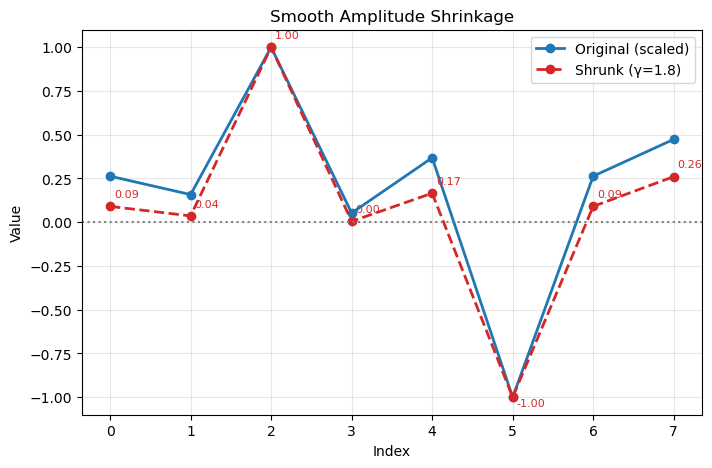

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# --- Original data ---
dd = np.array([2, 1, 9, 0, 3, -10, 2, 4], dtype=float)

# --- Normalize to [-1, 1] ---
d = 2 * (dd - dd.min()) / (dd.max() - dd.min()) - 1

# --- Define smooth shrinkage function ---
gamma = 1.8  # higher => more pronounced shrinkage
shrunk = np.sign(d) * np.abs(d) ** gamma

# --- Quantum visualization idea (no measurement here) ---
qc = QuantumCircuit(1)
qc.h(0)
qc.draw('mpl')

# --- Plot overlapped signals ---
plt.figure(figsize=(8,5))
plt.plot(range(len(d)), d, 'o-', label='Original (scaled)', color='tab:blue', lw=2)
plt.plot(range(len(shrunk)), shrunk, 'o--', label=f'Shrunk (γ={gamma})', color='tab:red', lw=2)
plt.axhline(0, color='gray', ls=':')
plt.xticks(range(len(d)))
plt.legend()
plt.title("Smooth Amplitude Shrinkage")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

for i, (x, y) in enumerate(zip(range(len(d)), shrunk)):
    plt.text(i + 0.05, y + 0.05*np.sign(y), f"{y:.2f}", color='tab:red', fontsize=8)

plt.savefig("ex10smooth.png", dpi=300, bbox_inches="tight")
plt.savefig("ex10smooth.pdf", dpi=300, bbox_inches="tight")
plt.show()
 


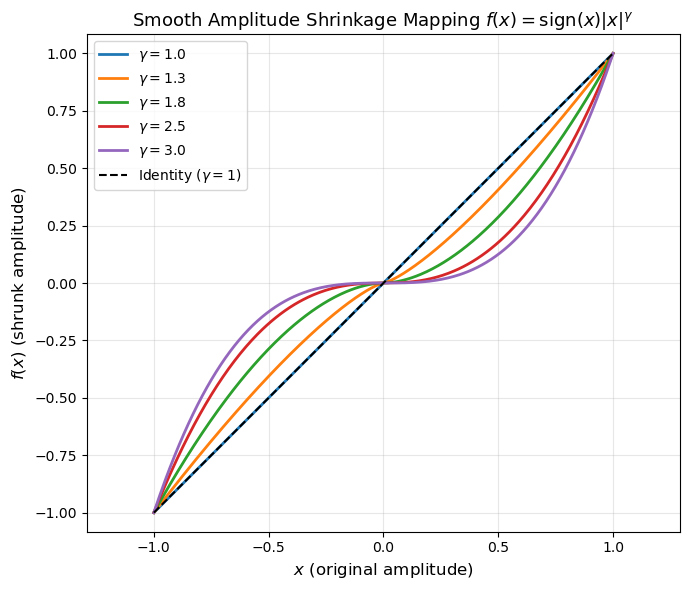

In [6]:
# ============================================================
# Smooth Shrinkage Mapping Visualization
# Quantum-Inspired Amplitude Shrinkage via |x|^γ
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ----- 1. Define range and shrinkage function -----
x = np.linspace(-1, 1, 400)

def shrink(x, gamma):
    return np.sign(x) * (np.abs(x) ** gamma)

# ----- 2. Choose gamma values -----
gammas = [1.0, 1.3, 1.8, 2.5, 3.0]

# ----- 3. Plot -----
plt.figure(figsize=(7, 6))
for g in gammas:
    plt.plot(x, shrink(x, g), lw=2, label=f"$\gamma={g}$")

# ----- 4. Add identity line for comparison -----
plt.plot(x, x, 'k--', lw=1.5, label="Identity ($\gamma=1$)")

# ----- 5. Format plot -----
plt.title("Smooth Amplitude Shrinkage Mapping $f(x)=\\text{sign}(x)|x|^{\\gamma}$", fontsize=13)
plt.xlabel("$x$ (original amplitude)", fontsize=12)
plt.ylabel("$f(x)$ (shrunk amplitude)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc="upper left")
plt.axis('equal')

# ----- 6. Save and show -----
plt.tight_layout()
#plt.savefig("shrinkage_mapping.png", dpi=300, bbox_inches='tight')

plt.savefig("ex10rule.png", dpi=300, bbox_inches="tight")
plt.savefig("ex10rule.pdf", dpi=300, bbox_inches="tight")

plt.show()
